# Worm Moebius

In this notebook, we implement the worm algorithm for the Moebius code for $d = 2 p$ with $p$ odd prime. 

In [1]:
from jax.typing import ArrayLike
import jax.numpy as jnp
from functools import partial
import numpy as np
from typing import Dict
from coherentinfo.moebius_two_odd_prime import MoebiusCodeTwoOddPrime
from coherentinfo.errormodel import ErrorModelLindbladTwoOddPrime
from coherentinfo.worm import (
    worm_coherent_information
)
import time
import json
import os
import jax
n_cpus = os.cpu_count()
n_used_cpus = n_cpus
print("Number of CPUs available: {}".format(n_cpus))
print("Number of used CPUs: {}".format(n_used_cpus))
jax.config.update('jax_num_cpu_devices', n_used_cpus)
# jax.config.update("jax_log_compiles", True)
# Devices assumed by JAX
print(jax.devices())

Number of CPUs available: 16
Number of used CPUs: 16
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15)]


In [22]:
moebius_setup = {"length": 5, "width": 5, "p": 3}

worm_setup = {}
worm_setup["num_samples"] = 20 * n_cpus
worm_setup["num_worms"] = 200
worm_setup["burn_in_steps"] = 1000
worm_setup["max_worm_steps"] = 2000
plaquette_keys_setup = {}
plaquette_keys_setup["worm_master_seed"] = 144
plaquette_keys_setup["error_master_seed"] = 42

vertex_keys_setup = {}
vertex_keys_setup["worm_master_seed"] = 144
vertex_keys_setup["error_master_seed"] = 42
gamma_t = 0.6

In [23]:
moebius_code = MoebiusCodeTwoOddPrime(
    length=moebius_setup["length"], width=moebius_setup["width"], d=2 * moebius_setup["p"])
em_lindblad = ErrorModelLindbladTwoOddPrime(
    moebius_code.num_edges, d=2 * moebius_setup["p"], gamma_t=gamma_t
)
print(f"Single error probabilities: {em_lindblad.get_probabilities()}")

Single error probabilities: [0.41982317 0.21546587 0.06276795 0.02370939 0.0627678  0.2154658 ]


In [24]:
coherent_information, plaquette_conditional_entropy, vertex_conditional_entropy = worm_coherent_information(
    gamma_t=gamma_t,
    moebius_setup=moebius_setup,
    worm_setup=worm_setup,
    plaquette_keys_setup=plaquette_keys_setup,
    vertex_keys_setup=vertex_keys_setup
)

print(f"Plaquette conditional entropy: {plaquette_conditional_entropy}")
print(f"Vertex conditional entropy: {vertex_conditional_entropy}")
print(f"Coherent Information: {coherent_information}")

Plaquette conditional entropy: 0.9627461433410645
Vertex conditional entropy: 0.9940398335456848
Coherent Information: -0.9567859768867493


In [25]:
num_gamma = 25
gamma_min = 0.08
gamma_max = 0.6
gamma_t_list = (np.linspace(gamma_min, gamma_max, num_gamma)).tolist()

result = {}
result["gamma_t"] = gamma_t_list

result["worm_setup"] = worm_setup
result["moebius_setup"] = moebius_setup

max_integer = 1_000_000
result["plaquette_worm_master_seed"] = (
    np.random.randint(0, max_integer, num_gamma)).tolist()
result["plaquette_error_master_seed"] = (
    np.random.randint(0, max_integer, num_gamma)).tolist()

result["vertex_worm_master_seed"] = (
    np.random.randint(0, max_integer, num_gamma)).tolist()
result["vertex_error_master_seed"] = (
    np.random.randint(0, max_integer, num_gamma)).tolist()

# This is to save on which machine the results are obtained
with open('/sys/devices/virtual/dmi/id/product_name') as f:
    result["machine_id"] = f.read()

with open('/sys/devices/virtual/dmi/id/sys_vendor') as f:
    result["vendor"] = f.read()

result["number_of_available_cpus"] = n_cpus
result["number_of_used_cpus"] = n_cpus

result["plaquette_conditional_entropy"] = []
result["vertex_conditional_entropy"] = []
result["coherent_information"] = []

In [26]:
start = time.time()
for index in range(num_gamma):
    plaquette_keys_setup = {}
    plaquette_keys_setup["worm_master_seed"] = result["plaquette_worm_master_seed"][index]
    plaquette_keys_setup["error_master_seed"] = result["plaquette_error_master_seed"][index]

    vertex_keys_setup = {}
    vertex_keys_setup["worm_master_seed"] = result["plaquette_worm_master_seed"][index]
    vertex_keys_setup["error_master_seed"] = result["plaquette_error_master_seed"][index]

    coherent_information, plaquette_ce, vertex_ce = worm_coherent_information(
        gamma_t=result["gamma_t"][index],
        moebius_setup=moebius_setup,
        worm_setup=worm_setup,
        plaquette_keys_setup=plaquette_keys_setup,
        vertex_keys_setup=vertex_keys_setup
    )

    print(f"Gamma: {result["gamma_t"][index]}")
    print(f"Coherent Information: {coherent_information}")

    result["plaquette_conditional_entropy"].append(plaquette_ce.tolist())
    result["vertex_conditional_entropy"].append(vertex_ce.tolist())
    result["coherent_information"].append(coherent_information.tolist())
end = time.time()

computation_time = end - start

result["computation_time"] = computation_time
result["time_unit"] = "sec"

Gamma: 0.08
Coherent Information: 1.0
Gamma: 0.10166666666666667
Coherent Information: 0.999483048915863
Gamma: 0.12333333333333334
Coherent Information: 0.9988150000572205
Gamma: 0.14500000000000002
Coherent Information: 0.9961763024330139
Gamma: 0.16666666666666669
Coherent Information: 0.9868499040603638
Gamma: 0.18833333333333335
Coherent Information: 0.9570931196212769
Gamma: 0.21000000000000002
Coherent Information: 0.9384390711784363
Gamma: 0.2316666666666667
Coherent Information: 0.8234748840332031
Gamma: 0.25333333333333335
Coherent Information: 0.7141996622085571
Gamma: 0.275
Coherent Information: 0.5438613891601562
Gamma: 0.2966666666666667
Coherent Information: 0.42925602197647095
Gamma: 0.31833333333333336
Coherent Information: 0.21437978744506836
Gamma: 0.34
Coherent Information: 0.03791159391403198
Gamma: 0.3616666666666667
Coherent Information: -0.1333768367767334
Gamma: 0.38333333333333336
Coherent Information: -0.29569506645202637
Gamma: 0.405
Coherent Information: -0

In [27]:
save = True

filename = ("coherent_information_moebius_length_" +
            str(moebius_setup["length"]) +
            "_width_" +
            str(moebius_setup["width"]) +
            "_p_" +
            str(moebius_setup["p"]) + ".json"
            )

if save:
    with open(filename, "w") as fp:
        json.dump(result, fp)

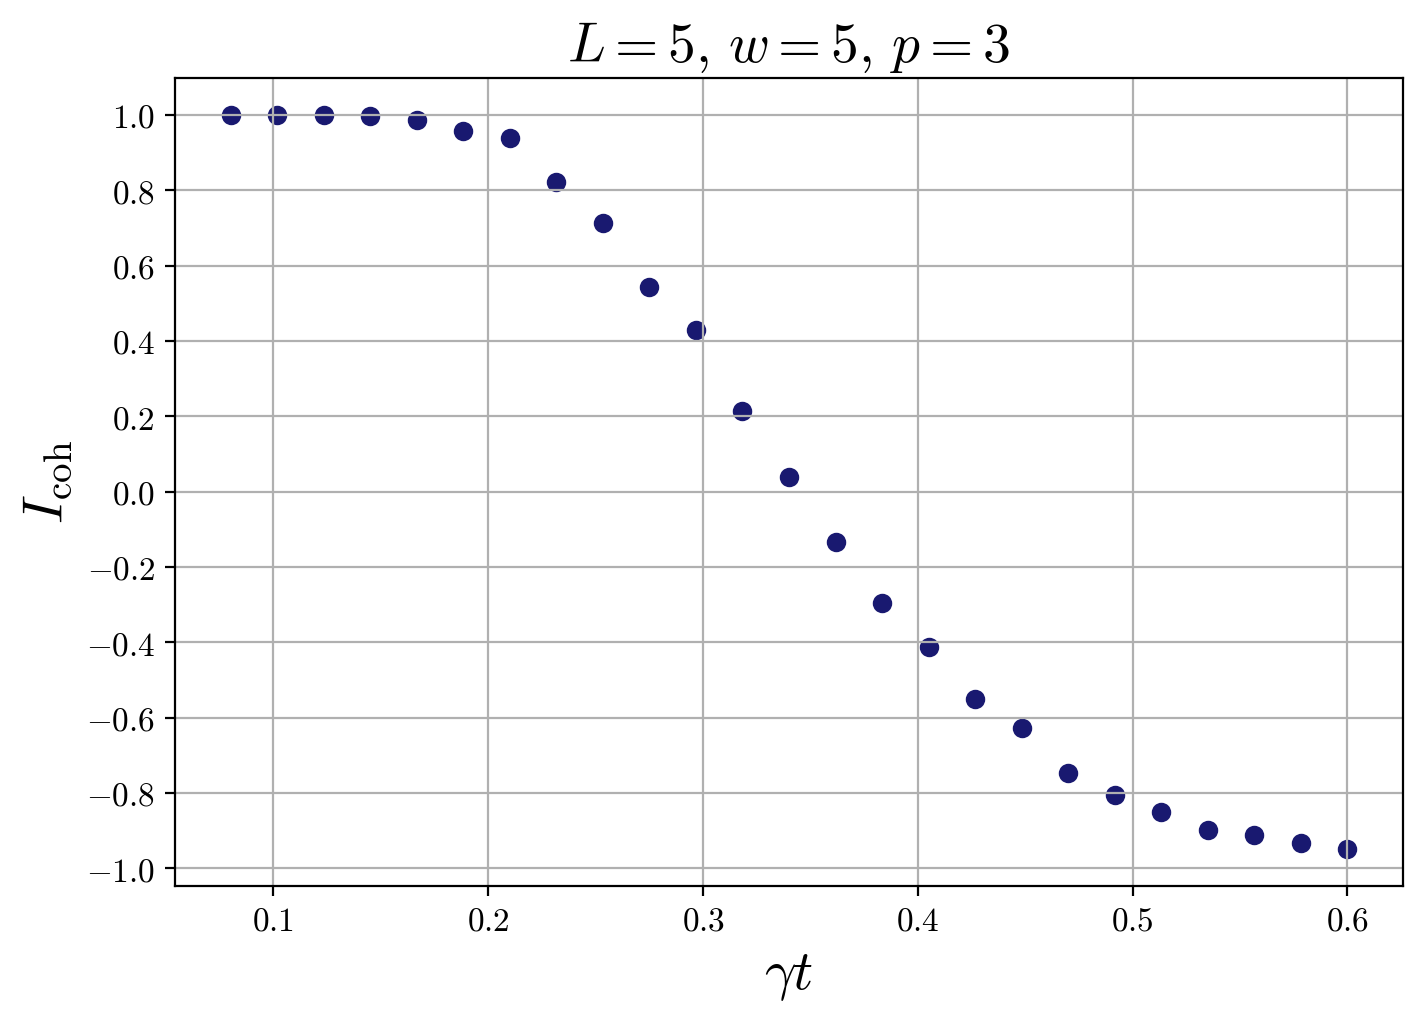

In [29]:
import matplotlib.pyplot as plt 
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'cm'

tex_rc_params = {
    'backend': 'ps',
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'legend.fontsize': 20,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': 'serif',
}

%matplotlib inline
%config InlineBackend.figure_format='retina'  # for hi-dpi displays

def plot_coherent_information(
    result: Dict,
    save: bool=False
):
    length = result["moebius_setup"]["length"]
    width = result["moebius_setup"]["width"]
    p = result["moebius_setup"]["p"]
    gamma_array = result["gamma_t"]
    coherent_info_array = result["coherent_information"]
    with plt.rc_context(tex_rc_params):
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
        ax.scatter(gamma_array, coherent_info_array, color="midnightblue")
        ax.set_xlabel("$\\gamma t$")
        x_ticks = [0.1 + 0.1 * x for x in range(6)]
        ax.set_xticks(x_ticks)
        x_ticks_labels = ['$0.1$', '$0.2$', '$0.3$', '$0.4$', '$0.5$', '$0.6$']
        ax.set_xticklabels(x_ticks_labels)
        y_ticks = [-1.0 + 0.2 * y for y in range(11)]
        ax.set_yticks(y_ticks)
        y_ticks_labels = ['$-1.0$', '$-0.8$', '$-0.6$', '$-0.4$', '$-0.2$', '$0.0$',
                          '$0.2$', '$0.4$', '$0.6$', '$0.8$', '$1.0$']
        ax.set_yticklabels(y_ticks_labels)
        ax.set_ylabel("$I_{\\mathrm{coh}}$")
        ax.grid()
        ax.set_title(f"$L= {length}, \\, w = {width}, \\, p={p}$")
        if save:
            plt.savefig("my_fig.svg", bbox_inches='tight', 
                        transparent=True, pad_inches=0)
        plt.show()

plot_coherent_information(result)